# Paper-Tiger 🐯
### A backtest that "beats the market" — does it, really?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats the market?: Not supported](https://img.shields.io/badge/Beats_the_market%3F-Not_supported-8b949e?style=flat-square)

A vendor sells a dual-momentum strategy with a shiny backtest: ride the strongest stock market, flee to bonds before crashes, beat buy-and-hold. We rebuild it faithfully on real ETFs and check the headline against the benchmarks a sceptic would actually use. The strategy is *real* — but the reason it sells turns out to be a paper tiger.

> 📓 **This is the plain-language layer.** The statistics, the decay test and the portfolio maths live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_tiger/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from paper_tiger import data, strategy as st

prices, tbill = data.fetch_etfs()          # cache-first; built by examples/verify.py --fetch
gem  = st.gem_returns(prices, tbill, cost_bps=20.0)
gem0 = st.gem_returns(prices, tbill, cost_bps=0.0)
spy  = st.buy_and_hold(prices, "US").loc[gem.index]
b40  = st.blend(prices).loc[gem.index]
def curve(s): return (1+s).cumprod()


## The answer first 🎯

| You might think… | The numbers say… |
|---|---|
| "It beats the market" | It **ties** buy-and-hold and **loses to a plain 60/40** on Sharpe. |
| "…because it's clever timing" | Its only real gift is a **shallower drawdown** (−23% vs −51%). |
| "So I should hold it" | A 60/40 you already own gives **more** risk-adjusted return for less effort. |

It isn't a fraud — it makes money, reliably. It just doesn't do the one thing the headline promises.

## 1 · The claim

Gary Antonacci's **dual momentum**: each month, hold whichever of US or foreign stocks has the stronger 12-month return — but only if that return beat Treasury bills; otherwise sit in bonds. The pitch: equity-like returns, **half the drawdown**, beats buy-and-hold.

## 2 · So what?

This is one of the most-cited retail quant strategies on the internet, sold in books and replicated on every backtest site. If "beats the market with less risk" is real, it's a free lunch. If it's a benchmarking illusion, millions are anchored on a number that doesn't hold up. Worth ten minutes to check.

## 3 · How would we even know?

Rebuild it on **real ETFs** (SPY, EFA, AGG) back to 2003, charge a realistic 20 bp every time it switches doors, and line it up against the two benchmarks that matter: **just owning SPY**, and a **boring monthly-rebalanced 60/40**. Then look at the equity curve *and* the drawdowns — because the whole sales pitch is about the drawdowns.

<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_5300\4045888823.py:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_yscale('log'); ax.set_title('Growth of \$1 — GEM vs the benchmarks (log scale)')
C:\Users\loutr\AppData\Local\Temp\ipykernel_5300\4045888823.py:6: SyntaxWarning: "\$"

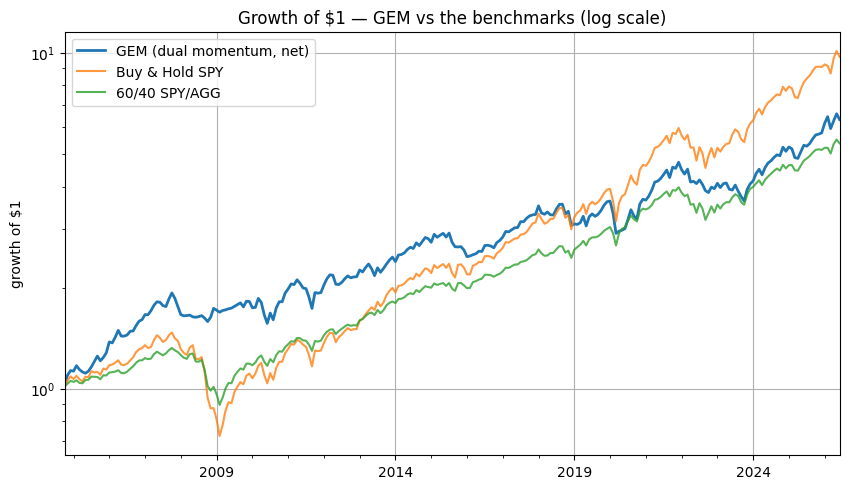

In [2]:
fig, ax = plt.subplots()
curve(gem).plot(ax=ax, label='GEM (dual momentum, net)', lw=2)
curve(spy).plot(ax=ax, label='Buy & Hold SPY', lw=1.5, alpha=.8)
curve(b40).plot(ax=ax, label='60/40 SPY/AGG', lw=1.5, alpha=.8)
ax.set_yscale('log'); ax.set_title('Growth of \$1 — GEM vs the benchmarks (log scale)')
ax.set_ylabel('growth of \$1'); ax.legend(); plt.show()

## 4 · The teardown — let's actually look

The headline table, and the picture that explains it.

In [3]:
rows = {'GEM (net)': st.summary(gem), 'Buy & Hold SPY': st.summary(spy), '60/40 SPY/AGG': st.summary(b40)}
tbl = pd.DataFrame(rows).T[['sharpe','cagr','vol_ann','max_drawdown']]
tbl.columns = ['Sharpe','CAGR','vol','max drawdown']
display(tbl.style.format({'CAGR':'{:.1%}','vol':'{:.1%}','max drawdown':'{:.1%}','Sharpe':'{:.2f}'}))

,Sharpe,CAGR,vol,max drawdown
GEM (net),0.74,8.9%,12.5%,-23.3%
Buy & Hold SPY,0.77,11.0%,15.1%,-50.8%
60/40 SPY/AGG,0.86,8.0%,9.6%,-32.3%


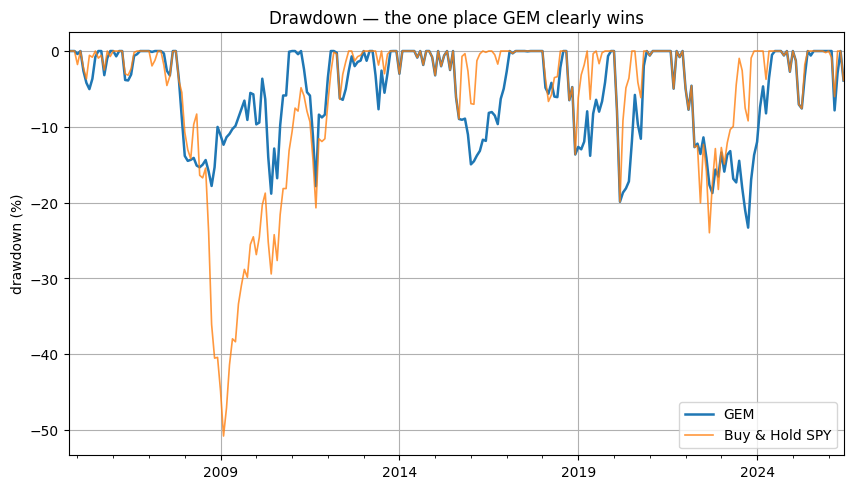

In [4]:
def underwater(s): c = curve(s); return c/c.cummax() - 1
fig, ax = plt.subplots()
(underwater(gem)*100).plot(ax=ax, label='GEM', lw=1.8)
(underwater(spy)*100).plot(ax=ax, label='Buy & Hold SPY', lw=1.2, alpha=.8)
ax.set_title('Drawdown — the one place GEM clearly wins'); ax.set_ylabel('drawdown (%)'); ax.legend(); plt.show()

**Read it plainly.** Same ballpark wealth as SPY, but the red 2008 canyon is half as deep — because GEM was sitting in bonds. That crash-cushion is real. It just isn't *extra return*: the 60/40 line in the first chart gets a higher Sharpe without any timing at all.

## 5 · The verdict

**Signal: Real** — it genuinely makes money (the quants notebook puts a t-stat of 3.4 on it). **Tradability: Fragile** — its edge is one-dimensional crash protection that leans on a single 2008 and has faded since. **Beats the market?: Not supported** — it ties SPY and loses to 60/40. A real strategy wearing a paper-tiger headline.

## 6 · Could you actually trade it?

Yes — and that's the seductive part. It trades ~1.5×/year, costs are trivial (20 bp/switch barely dents it), and it's genuinely defensive. But "can you trade it" isn't the question; "does it beat the lazy alternative" is — and a 60/40 index portfolio wins on Sharpe with zero effort.

## 7 · Going further 🚪

The deep companion — [02_for_the_quants](02_for_the_quants.ipynb) — puts standard errors on every claim, shows the post-publication decay, and runs the portfolio test: does adding a GEM sleeve to a 60/40 help? (It trims drawdown but doesn't lift Sharpe.) Contrast with [Study 31 Trade-Winds](../../31-trade-winds/), where a trend sleeve *does* raise portfolio Sharpe — that's the difference between real diversification and a paper tiger.